In [2]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import networkx as nx
import importlib
import seaborn as sns
import os
import sys
import gempy as gp
import gempy_viewer as gpv
import contextily as cx
import openpnm as op
import networkx as nx
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
from matplotlib_scalebar.scalebar import ScaleBar
import random
# import cfpy

Setting Backend To: AvailableBackends.numpy


In [3]:
import utils.common
import utils.conduits
import utils.openkarst_network
import utils.geos
importlib.reload(utils.openkarst_network)
importlib.reload(utils.common)
importlib.reload(utils.geos)
importlib.reload(utils.conduits)
from utils.common import *
from utils.geos import * 
from utils.conduits import *
import utils.openkarst_network as okn


In [4]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

In [5]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14            # main text size
plt.rcParams['axes.labelsize'] = 16       # axis labels
plt.rcParams['axes.titlesize'] = 18       # title
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'      # Roman style
plt.rcParams['mathtext.it'] = 'Arial:italic' # Italic style
plt.rcParams['mathtext.bf'] = 'Arial:bold'   # Bold style

# Generate Single Straight Line Conduit

In [68]:
nodes = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/nodes.csv')
edges = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/edges.csv')

In [21]:
plot_3D_network(nodes, edges, node_color='type')

In [24]:
edges['length'] = np.sqrt((edges.x_0 - edges.x_1)**2 + (edges.y_0 - edges.y_1)**2 + (edges.z_0 - edges.z_1)**2)

# Generate Straight Line Multi-conduit Network

In [152]:
new_nodes = pd.read_csv('../../data/networks/multiconduit/straight_n5/nodes.csv', index_col=False)
new_edges = pd.read_csv('../../data/networks/multiconduit/straight_n5/edges.csv', index_col=False)
new_edges = extract_edge_coordinates(new_nodes, new_edges)
new_nodes, new_edges = densify_edges(new_nodes, new_edges, density_factor=1)
new_nodes, new_edges = reset_node_ids(new_nodes, new_edges)

In [155]:
new_nodes.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/n_12/nodes.csv', index = False)
new_edges.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/n_12/edges.csv', index = False)

# Generate Geologic Model

In [6]:
#TODO: generate cost gradient vertically
nx = grid_parameters['nx']
ny = grid_parameters['ny']
nz = grid_parameters['nz']
max_cost = .8
min_cost_ratio = 0.1
vertical_cost_gradient= 0.1
geology_costs = {}
geology_model = {i : True for i in range(1, nz*2+1)}
for i in range (1,nz+1):
    geology_costs[i] = max_cost - (i-1) * vertical_cost_gradient
    geology_costs[i + nz] = geology_costs[i] * min_cost_ratio
    
geo = np.random.randint(1, 3, size = (nx, ny, nz))



In [7]:
from scipy.ndimage import gaussian_filter

field = np.random.rand(nx, ny, nz)
smooth_field = gaussian_filter(field, sigma=5)
smooth_field = (smooth_field - smooth_field.min()) / (smooth_field.max() - smooth_field.min())

bins = [0.5]   # thresholds
geo = np.digitize(smooth_field, bins) + 1

In [6]:
#banded costs
geo[:,:,:] = 1
thickness = 10
offsets = np.arange(-300, 300, 60)  # This creates an array of offsets from -180 to 180 with a step of 60
i, j = np.indices((nx, ny))
mask_xy = np.abs(i + j -nx) <= thickness
for offset in offsets:
    mask_xy |= np.abs(i+ j - nx - offset) <= thickness

geo[mask_xy] = 2

In [8]:
#map geology types to field
for i in range(1,nz+1):
    geo[:,:, i-1] = np.where(geo[:,:, i-1] == 1, i,i + nz) 
geo = np.flip(geo, axis=2)

In [11]:
import pyvista as pv

# geo = 3D integer array

grid = pv.ImageData()

grid.dimensions = np.array(geo.shape) + 1
grid.cell_data["unit"] = geo.flatten(order="F")
grid.spacing = (dx, dy, dz * 10)
plotter = pv.Plotter()

plotter.add_mesh(
    grid,
    scalars="unit",
    show_edges=False,
    opacity=0.7,
)
plotter.add_camera_orientation_widget()
plotter.show()

Widget(value='<iframe src="http://localhost:56278/index.html?ui=P_0x2e7320f28d0_0&reconnect=auto" class="pyvis…

# Generate Network with PyKasso

In [9]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

In [10]:
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [11]:
settings = 'dye_trace'

In [84]:
DEM_path = '../../data/DEM/dem_1m_m.bil'
crs = 'EPSG:32615'
grid = read_DEM_data(DEM_path, x0, x1, y0, y1, dx, dy, crs)

In [12]:
azimuth = 350
dip = 0 #np.pi/180/5
slope = np.tan(dip)
azimuth_rad = np.radians(azimuth)
dz_dx = slope * np.cos(azimuth_rad)  # Change in Z per unit X
dz_dy = slope * np.sin(azimuth_rad)  # Change in Z per unit Y
x, y = np.meshgrid(np.arange(nx), np.arange(ny))
grid = z1 - ((nx - x-1)* dx * dz_dx) + ((ny - y-1) * dy * dz_dy)

In [86]:
bedrock = grid - 3#assume bedrock is right below surface

In [13]:
# top = np.load('../../data/DEM/dem_grid_bear_spring.npy')
model_parameters[settings]['domain']['topography'] = grid.T
model_parameters[settings]['geology'] = {
        'data' : geo,
        'costs' : geology_costs,
        'model' : geology_model
    }
model_parameters[settings]['sks']['ratio'] = 1
# model_parameters[settings]['domain']['water_table'] = grid.T - 4
# model_parameters[settings]['domain']['bedrock'] = bedrock.T

In [14]:
for i in range(1):
    app.model.generate(model_parameters[settings])
    # print(app.model.model_parameters['sks']['seed'])


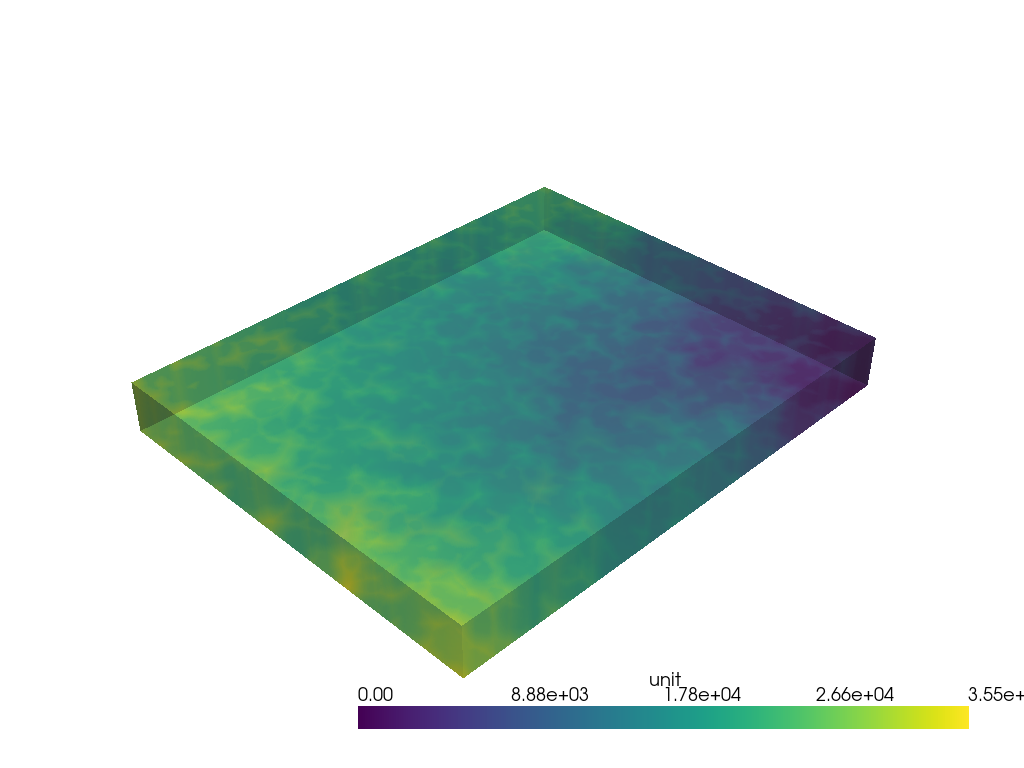

In [18]:
grid = pv.ImageData()

grid.dimensions = np.array(app.model.fmm['fastMarchingOutput']['values'].shape) + 1
grid.cell_data["unit"] = app.model.fmm['fastMarchingOutput']['values'].flatten(order="F")
grid.spacing = (dx, dy, dz * 10)
plotter = pv.Plotter()

plotter.add_mesh(
    grid,
    scalars="unit",
    show_edges=False,
    opacity=0.7,
)

plotter.show()

In [ ]:
#TODO: use time map to generate elevation changes 
app.model.maps['time']

3

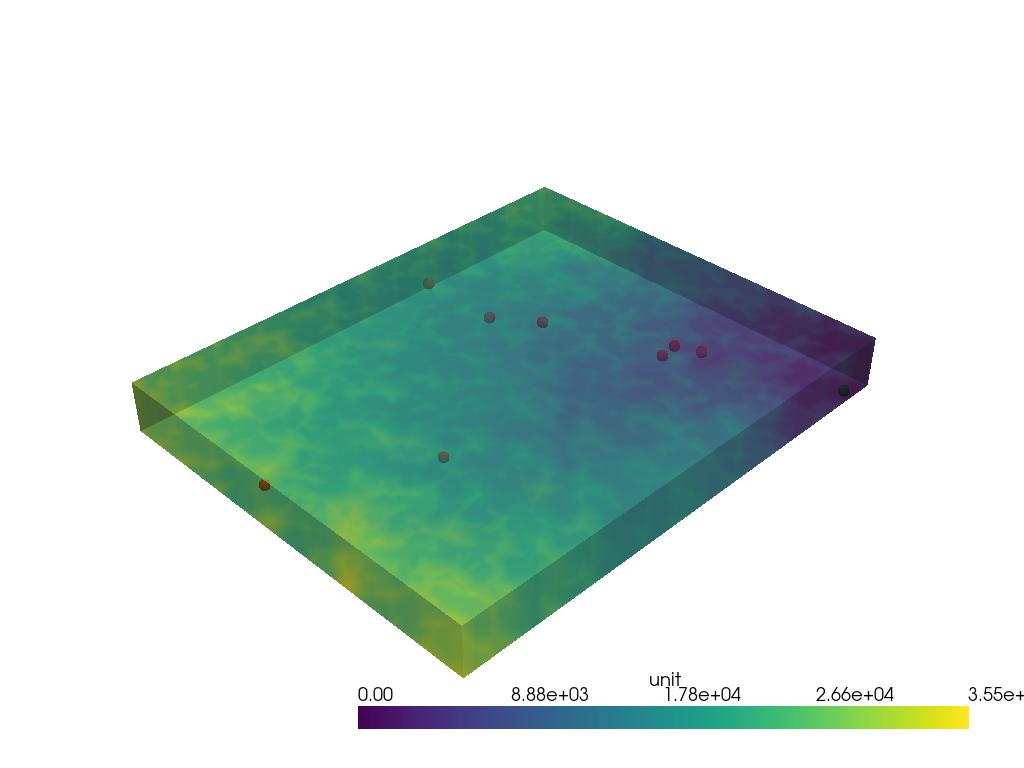

In [27]:
grid = pv.ImageData()
data = app.model.maps['time'][2]
grid.dimensions = np.array(data.shape) + 1
grid.cell_data["unit"] = data.flatten(order="F")
grid.spacing = (dx, dy, dz * 10)
grid.origin = (x0, y0, z0)

plotter = pv.Plotter()


plotter.add_mesh(
    grid,
    scalars="unit",
    show_edges=False,
    opacity=0.7,
)
inlets = nodes[nodes.type == 'inlet'][['x', 'y', 'z']].values
outlets = nodes[nodes.type == 'outlet'][['x', 'y', 'z']].values
plotter.add_points(
    inlets,
    color="red",
    point_size=12,
    render_points_as_spheres=True,
)
plotter.add_points(
    outlets,
    color="green",
    point_size=12,
    render_points_as_spheres=True,
)

plotter.show()

In [21]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
# nodes['z'] = 395 # set all nodes to the same elevation to create a 2D network
edges.columns = ['from_id', 'to_id']
edges = extract_edge_coordinates(nodes, edges)

In [22]:
nodes, edges = reduce_node_density(nodes, edges, 10)
nodes, edges = reset_node_ids(nodes, edges)
edges = extract_edge_coordinates(nodes, edges)
network = okn.OpenKarstNetwork(nodes = nodes, edges = edges)
network.load_cave_data()
network.conduit_lengths()

c:\Users\huan1428\.conda\envs\pyKasso\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning:

Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.



Text(101.30555555555556, 0.5, '')

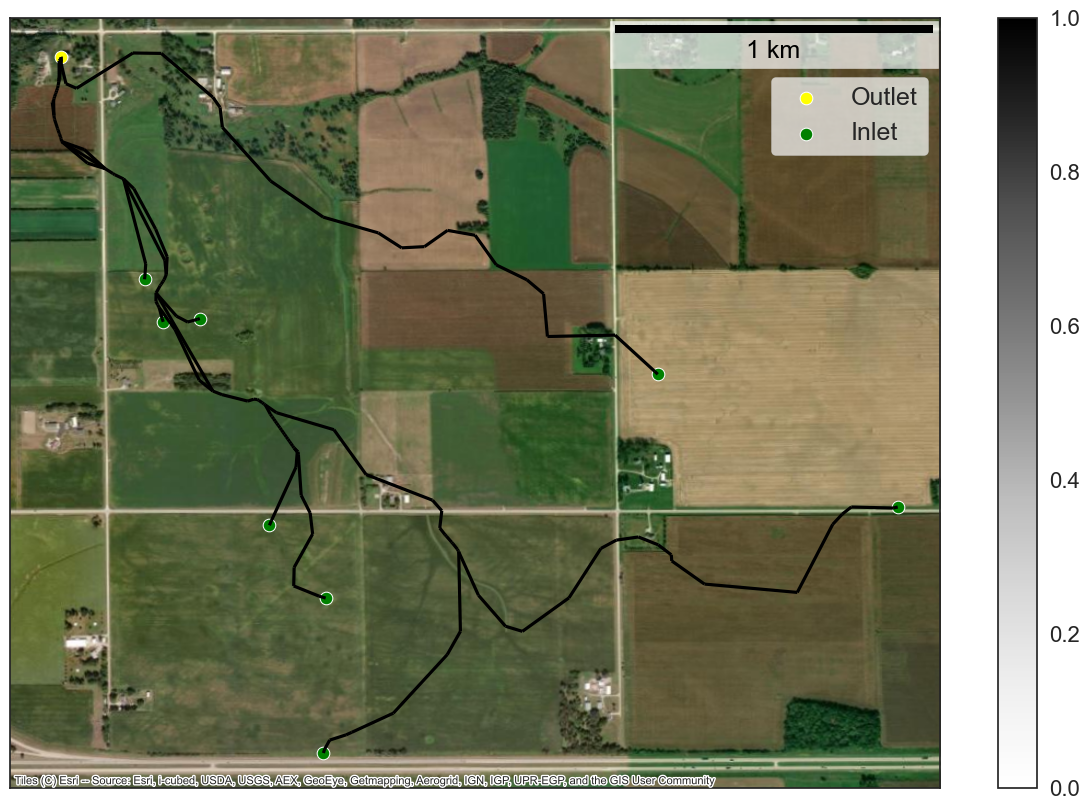

In [95]:
fig, ax = plt.subplots(figsize = (15,10))
# network_dir = 'anastomotic_simple_clean'
# nodes = pd.read_csv(f'../steady_state/conduit_geometry_test/networks/{network_dir}/nodes.csv')
# edges = pd.read_csv(f'../steady_state/conduit_geometry_test/networks/{network_dir}/edges.csv')
plot_2D_network(nodes, edges, grid = False, ax =ax )
# springshed = load_geojson('../../data/geo_data/Bear_Springshed.geojson')
# sinkholes = pd.read_csv('../../data/geo_data/sinkholes/sinkholes_dye_trace_2d.csv', header = None)
# spring = pd.read_csv('../../data/geo_data/springs/springs_coords.txt', delimiter = ' ', header = None)

# springshed.plot(ax= ax, alpha = 0.6, color = 'grey')
sns.scatterplot(nodes[(nodes.type == 'outlet')], x = 'x', y = 'y', color = 'yellow', label = 'Outlet')
sns.scatterplot(nodes[(nodes.type == 'inlet')], x = 'x', y = 'y', color = 'green', label = 'Inlet')

source = cx.providers.Esri.WorldImagery
scalebar= ScaleBar(1, fixed_units = 'km', fixed_value = 1, box_alpha = 0.7, color = 'black')
ax.add_artist(scalebar)
# sns.scatterplot(ax = ax, data = nodes[nodes.type == 'outfall'], x= 'x', y ='y', color = 'blue', label = 'spring')
cx.add_basemap(
    ax, 
    crs='EPSG:32615', 
    source=source, 
    zoom="auto"
)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, labelleft=False)
leg = plt.legend(frameon=True)
leg.get_frame().set_alpha(0.7)
leg.get_frame().set_facecolor("white")
leg.set_zorder(10)
leg.set_bbox_to_anchor((1, 0.94))
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "legend.fontsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})
plt.xlabel(None)
plt.ylabel(None)
# plt.savefig('test_fig', transparent = True)

In [17]:
plot_3D_network(nodes, edges, node_color = 'type')

<Axes: >

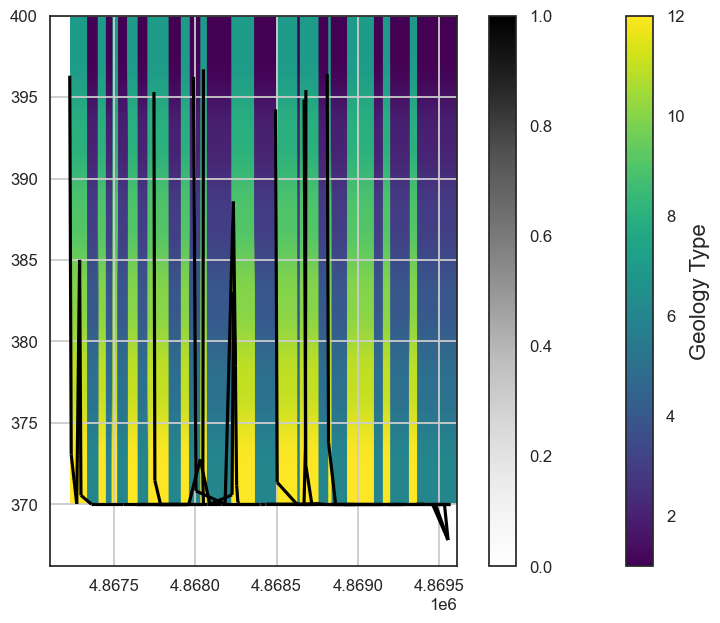

In [65]:
fig, ax = plt.subplots()
cbar = ax.imshow(geo[1,:,:].T, extent = (y0, y1, z0, z1),origin = 'lower', aspect = 100, cmap = 'viridis')
plt.colorbar(cbar, label='Geology Type')
plot_2D_network(nodes, edges, axes = ('y','z'), ax =ax)



<Axes: >

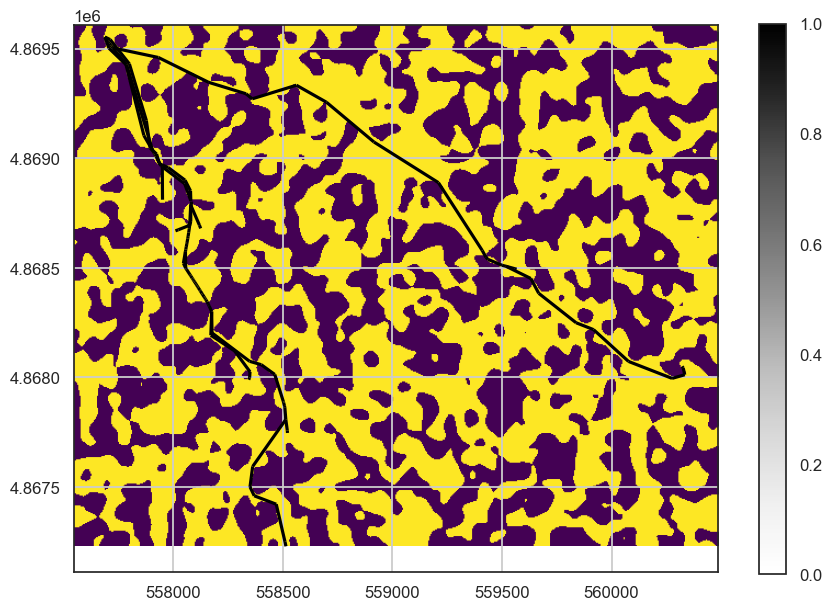

In [18]:
fig, ax = plt.subplots()
cbar = ax.imshow(np.flipud(geo[:,:,2].T), extent = (x0, x1, y0, y1), cmap = 'viridis')
# plt.colorbar(cbar, ax = ax, label = 'Geological Unit')
plot_2D_network(nodes, edges, ax = ax, axes = ('x', 'y'))

In [23]:
from shapely.geometry import LineString

def check_intersection(edge1, edge2, tol = 1e-6):
    line1 = LineString([(edge1[0], edge1[1], edge1[2]), (edge1[3], edge1[4], edge1[5])])
    line2 = LineString([(edge2[0], edge2[1], edge2[2]), (edge2[3], edge2[4], edge2[5])])
    return line1.intersects(line2) and line1.intersection(line2).length > tol
    # Unpack edge coordinates

In [25]:
edges = network.edges

In [26]:
max_length = edges.length.max()
checked_edges = set() # keep track of edges that have already been checked for intersection to avoid redundant checks
for idx, edge in edges.iterrows():
    checked_edges.add(idx)
    edge_coord = edge[['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1']].values #edge coordinates
    edge_midpoint = [(edge.x_0 + edge.x_1)/2, (edge.y_0 + edge.y_1)/2, (edge.z_0 + edge.z_1)/2]
    #bounding box, limited by the max conduit length of system 
    bounds = {'x_0': min(edge.x_0, edge.x_1) - max_length, 'x_1': max(edge.x_0, edge.x_1) + max_length,
              'y_0': min(edge.y_0, edge.y_1) - max_length, 'y_1': max(edge.y_0, edge.y_1) + max_length,
              'z_0': min(edge.z_0, edge.z_1) - max_length, 'z_1': max(edge.z_0, edge.z_1) + max_length}
    #only nodes within the bounding box will be tested
    nodes_to_test = nodes[((nodes.x >= bounds['x_0']) & (nodes.x <= bounds['x_1']) &
                           (nodes.y >= bounds['y_0']) & (nodes.y <= bounds['y_1']) &
                           (nodes.z >= bounds['z_0']) & (nodes.z <= bounds['z_1']))]
    nodes_to_test = nodes_to_test[(nodes_to_test.id.isin([edge.from_id, edge.to_id]) == False)]
    edges_to_test = edges[edges.from_id.isin(nodes_to_test.id) | edges.to_id.isin(nodes_to_test.id)]
    edges_to_test = edges_to_test[~edges_to_test.index.isin(checked_edges)] #exclude edges that have already been tested in previous iterations
    for test_idx, test_edge in edges_to_test.iterrows():
        test_edge_coord = test_edge[['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1']].values
        if check_intersection(edge_coord, test_edge_coord):
            print(f"Edge {edge.name} intersects with edge {test_edge.name}")

In [27]:
plot_2D_network(nodes, edges, axes = ('x', 'y'),node_color = nodes.degree)
plt.ylim(4869000,)
plt.xlim(557500,558500)


AttributeError: 'DataFrame' object has no attribute 'degree'

## Changing Slope / Node Density

In [53]:
network_dir = '../steady_state/conduit_geometry_test/networks/single_conduit_vert_tort'
nodes = pd.read_csv(f"{network_dir}/nodes.csv")
edges = pd.read_csv(f"{network_dir}/edges.csv")
edges = conduit_lengths(nodes, edges)
edges = conduit_slopes(nodes, edges)

In [59]:
nodes, edges = adjust_node_spacing(nodes, edges, spacing = 2)
edges = extract_edge_coordinates(nodes, edges)

In [60]:
plot_3D_network(nodes, edges, node_color = 'type')

In [20]:
slope = 0.0008
dip = np.arctan(slope)
elevs= create_sloped_array(grid_parameters['nx'], grid_parameters['ny'], grid_parameters['dx'], grid_parameters['dy'], dip = dip, azimuth = 350, z1 = 400)

In [21]:
def calculate_azimuth(node_1, node_2):
    dx = node_1[0] - node_2[0]
    dy = node_1[1] - node_2[1]
    azimuth = np.arctan2(dy, dx)
    return azimuth

In [25]:
n1 = nodes[nodes.type =='inlet'].iloc[2][['x', 'y', 'z']]
n2 = nodes[nodes.type =='outlet'].iloc[0][['x', 'y', 'z']]
az = calculate_azimuth(n1, n2)
grid = create_sloped_array(grid_parameters['nx'], grid_parameters['ny'], grid_parameters['dx'], grid_parameters['dy'], dip = dip, azimuth = az, z1 = 400)
nodes, edges = project_conduit_elevations(nodes, edges, grid, x0, y1, grid_parameters['dx'], grid_parameters['dy'])
# nodes.loc[nodes.type=='inlet', 'z'] = nodes.loc[nodes.type=='inlet', 'z'] + 2
edges = extract_edge_coordinates(nodes, edges)

In [26]:
plot_3D_network(nodes, edges, show_nodes = False)

In [27]:
network_dir = '../steady_state/conduit_geometry_test/networks'
save_network(nodes, edges, network_dir, 'anastomotic_low_slope')


Network saved to ../steady_state/conduit_geometry_test/networks


In [61]:
nodes_1, edges_1 = rescale_slope(nodes, edges, alpha = 0.1, reference_id = nodes[nodes.type == 'outlet'].id.iloc[0])

<Axes: >

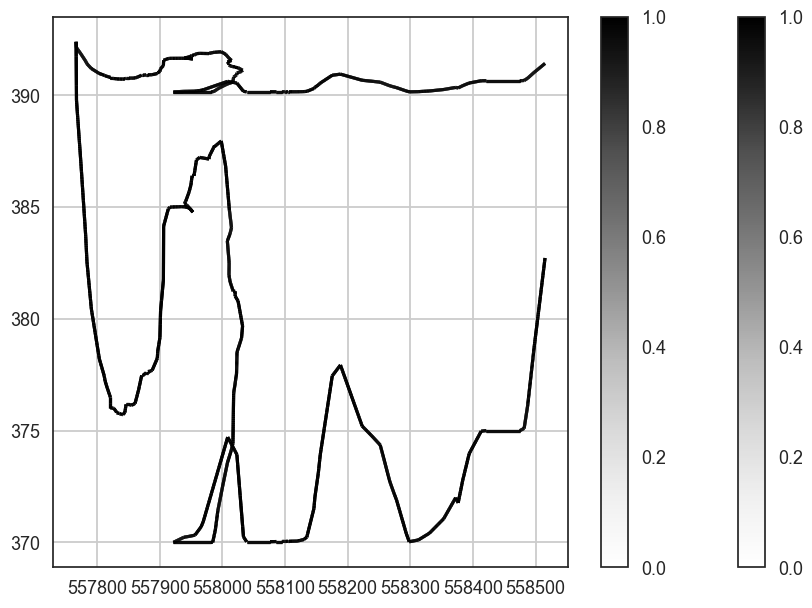

In [62]:
fig, ax = plt.subplots()
plot_2D_network(nodes, edges, axes = ('x', 'z'), ax = ax)
plot_2D_network(nodes_1, edges_1, axes = ('x', 'z'), ax = ax)

In [64]:
nodes.to_csv(f"{network_dir}/nodes.csv", index = False)
edges.to_csv(f"{network_dir}/edges.csv", index = False )

In [63]:
os.makedirs(f"{network_dir}_low_slope", exist_ok = True)
nodes_1.to_csv(f"{network_dir}_low_slope/nodes.csv", index = False)
edges_1.to_csv(f"{network_dir}_low_slope/edges.csv", index = False )

# Embedding Network in Fracture Lattice

In [73]:
buffer = 20
xmin = nodes.x.min() - buffer
xmax = nodes.x.max() + buffer
ymin = nodes.y.min() - buffer
ymax = nodes.y.max() + buffer
zmin = nodes.z.min() - buffer
zmax = nodes.z.max() + buffer
lattice_dx = 100
lattice_dy = 100
lattice_dz = 5
lattice_nx = (xmax - xmin) // lattice_dx
lattice_ny = (ymax - ymin) // lattice_dy
lattice_nz = (zmax - zmin) // lattice_dz
#make arrays for nodes
X, Y, Z = np.arange(xmin, xmax, lattice_dx), np.arange(ymin, ymax, lattice_dy), np.arange(zmin, zmax, lattice_dz)
lattice_x, lattice_y, lattice_z = np.meshgrid(X, Y, Z, indexing = 'ij')
cube_lattice = op.network.Cubic(shape = (lattice_nx, lattice_ny, lattice_nz), spacing = (lattice_dx, lattice_dy, lattice_dz))
lattice_nodes = pd.DataFrame({'id' : cube_lattice.Ps, 'x': cube_lattice.coords[:,0] + xmin, 'y': cube_lattice.coords[:,1] + ymin, 'z': cube_lattice.coords[:,2] + zmin})
lattice_nodes['type'] = 'lattice'
lattice_edges = pd.DataFrame({'from_id' : cube_lattice.conns[:,0], 'to_id' : cube_lattice.conns[:,1]})
lattice_edges = extract_edge_coordinates(lattice_nodes, lattice_edges)
lattice_nodes['id'] = lattice_nodes.id + nodes.id.max() + 1
lattice_edges[['from_id', 'to_id']] = lattice_edges[['from_id', 'to_id']] + nodes.id.max() + 1


In [74]:
conduit_network = network.geometry

In [75]:
lattice_edges

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1
0,129,130,557719.0,4867260.0,352.5,557719.0,4867260.0,357.5
1,130,131,557719.0,4867260.0,357.5,557719.0,4867260.0,362.5
2,131,132,557719.0,4867260.0,362.5,557719.0,4867260.0,367.5
3,132,133,557719.0,4867260.0,367.5,557719.0,4867260.0,372.5
4,133,134,557719.0,4867260.0,372.5,557719.0,4867260.0,377.5
...,...,...,...,...,...,...,...,...
22082,7599,7898,560119.0,4869460.0,392.5,560219.0,4869460.0,392.5
22083,7600,7899,560119.0,4869460.0,397.5,560219.0,4869460.0,397.5
22084,7601,7900,560119.0,4869460.0,402.5,560219.0,4869460.0,402.5
22085,7602,7901,560119.0,4869460.0,407.5,560219.0,4869460.0,407.5


In [ ]:
for node in network.nodes.iterrows():
    #find closest lattice node and add a conduit edge between them
    x, y, z = node[1]['x'], node[1]['y'], node[1]['z']

(0, id               0
x         558515.0
y        4867230.0
z       395.248532
type         inlet
d                1
Name: 0, dtype: object)
(1, id                   1
x        557713.237895
y       4869541.382278
z           370.284634
type          junction
d                    1
Name: 1, dtype: object)
(2, id                   2
x        558332.917495
y       4869294.060698
z                370.0
type          junction
d                    1
Name: 2, dtype: object)
(3, id                   3
x        558510.586974
y       4867250.489438
z           370.493206
type          junction
d                    1
Name: 3, dtype: object)
(4, id                   4
x        558047.197709
y       4868521.294576
z           371.427716
type          junction
d                    1
Name: 4, dtype: object)
(5, id                   5
x         558162.21473
y       4869346.307857
z                370.0
type          junction
d                    1
Name: 5, dtype: object)
(6, id                   6
x

# Calculate Metrics

In [24]:
def bounding_box(nodes):
    x_min = nodes.x.min()
    x_max = nodes.x.max()
    y_min = nodes.y.min()
    y_max = nodes.y.max()
    z_min = nodes.z.min()
    z_max = nodes.z.max()
    return x_min, x_max, y_min, y_max, z_min, z_max
def bounding_box_2D(nodes):
    x_min = nodes.x.min()
    x_max = nodes.x.max()
    y_min = nodes.y.min()
    y_max = nodes.y.max()
    return x_min, x_max, y_min, y_max
def index(nodes, edges, mode, extent_method = 'bounding_box',verbose = True):
    temp_nodes = nodes.copy()
    temp_edges = edges.copy()
    if mode == 'HI':
        temp_nodes['z'] = 0 # set all nodes to the same elevation to create a 2D network
        temp_edges['z_0'] = 0
        temp_edges['z_1'] = 0
    temp_edges = conduit_lengths(temp_nodes, temp_edges)
    total_length = temp_edges.length.sum()
    print_verbose(f"Total conduit length: {total_length}", verbose)
    if extent_method == 'bounding_box':
        x_min, x_max, y_min, y_max, z_min, z_max = bounding_box(temp_nodes)
        if mode == 'HI':
            max_extent = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2)
        elif mode == "VI":
            max_extent =(z_max - z_min)
        else:
            max_extent = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2 + (z_max - z_min)**2)

        print_verbose(f"Max extent, bounding box: {max_extent}", verbose)
    elif extent_method == 'straight_line':
        max_extent = 0
        for outlet in nodes[nodes.type == 'outlet'].itertuples():
            for inlet in nodes[nodes.type == 'inlet'].itertuples():
                d = np.sqrt((outlet.x - inlet.x)**2 + (outlet.y - inlet.y)**2 + (outlet.z - inlet.z)**2)
                max_extent += d
        print_verbose(f"Max extent, straight line distance: {max_extent}", verbose)           
    #TODO: other methods
    index = total_length/max_extent
    return index

def VI(nodes, edges, extent_method = 'bounding_box', verbose = True):
    temp_nodes = nodes.copy()
    temp_edges = edges.copy()
    temp_edges = conduit_lengths(temp_nodes, temp_edges)
    total_length = temp_edges.length.sum()
    print_verbose(f"Total conduit length: {total_length}", verbose)
    if extent_method == 'bounding_box':
        x_min, x_max, y_min, y_max, z_min, z_max = bounding_box(temp_nodes)
        max_extent = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2 + (z_max - z_min)**2)
        print_verbose(f"Max extent of network: {max_extent}", verbose)
    VI = total_length/max_extent
    return VI

In [34]:
nodes = pd.read_csv("../steady_state/conduit_geometry_test/networks/slope_0008/nodes.csv")
edges = pd.read_csv("../steady_state/conduit_geometry_test/networks/slope_0008/edges.csv")
# simple_nodes, simple_edges = reduce_node_density(nodes, edges, 100)
# simple_nodes, simple_edges = reset_node_ids(simple_nodes, simple_edges)
network = okn.OpenKarstNetwork(nodes=nodes, edges = edges)
network.load_cave_data()
network.degree()
nodes['degree'] = network.degree
# simple_nodes['d'] = 1
# nodes['z'] = get_elev_from_coords(nodes.x, nodes.y, elevs, x0, y1, grid_parameters['dx'], grid_parameters['dy'])
# edges = extract_edge_coordinates(nodes, edges)
# nodes.to_csv("../steady_state/conduit_geometry_test/networks/anastomotic/nodes.csv", index = False)
# edges.to_csv("../steady_state/conduit_geometry_test/networks/anastomotic/edges.csv", index = False)

In [35]:
index(nodes, edges, mode='HI', extent_method = 'bounding_box', verbose = True)

Total conduit length: 2329.6072358487577
Max extent, bounding box: 2329.6072358487577


np.float64(1.0)

In [36]:
index(nodes, edges, mode = 'VI', extent_method = 'bounding_box', verbose = True)

Total conduit length: 2329.608094362416
Max extent, bounding box: 2.0


np.float64(1164.804047181208)

In [252]:
outlets = nodes[nodes.type == 'outlet'].id
outlet_edges = edges[edges.to_id.isin(outlets) | edges.from_id.isin(outlets)]
node_ids = set(outlet_edges.from_id.tolist() + outlet_edges.to_id.tolist())
i = 1
degrees = 3
while i < degrees: 
    outlet_edges = edges[edges.from_id.isin(node_ids) | edges.to_id.isin(node_ids)]
    node_ids |= set(outlet_edges.from_id.tolist() + outlet_edges.to_id.tolist())
    i+=1
outlet_nodes = nodes[nodes.id.isin(node_ids)]